In [1]:
import os, sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Basic Usage

In [2]:
from torchpenny import QLayer
import pennylane as qml
import torch

Quantum Layer without any input and parameters.

In [3]:
class QuantumLayer(QLayer):
    def __init__(self, *args, **kwargs):
        super(QuantumLayer, self).__init__(*args, **kwargs)
    def inner_gates(self, x=None):
        # You can define Pennylane circuit inside here.
        for w in range(self.wires):
            qml.Hadamard(wires=w)
            qml.PauliX(wires=w)
        qml.CNOT([0, 1])
    def measurement(self):
        return qml.probs()


In [4]:
quantum_layer = QuantumLayer(wires=3)

In [5]:
quantum_layer

QuantumLayer[Qnode, wires=3]()

In [6]:
print(qml.draw(quantum_layer.qnode)())

0: ──H──X─╭●─┤  Probs
1: ──H──X─╰X─┤  Probs
2: ──H──X────┤  Probs


In [7]:
quantum_layer()

tensor([0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250],
       dtype=torch.float64)

---

## QSubLayer module

`QSubLayer` module is a wrapper of `Operation` or `Template` class of Pennylane framework. In Pennylane, `Template` class also provides a block layer of quantum gates. However, their parameters are given by user and external source. Users have to manage the parameter dimension data for each `Template` in the circuit. 

Meanwhile in Pytorch all `Module` class manage their own parameter automatically. The input data and inherited weight and bias are seperated. To construct complicated circuit and program. This automatic management routine has benefit for rapid prototyping.

For example, in `torchpenny` there is a `ZZfeatureMap` layer.

In [8]:
from torchpenny.lib.qlayer.features import ZZfeatureMap

In [9]:
zz_feature = ZZfeatureMap(wires=4, param_received=False)
zz_feature_p = ZZfeatureMap(wires=4, param_received=True)

In [10]:
zz_feature, zz_feature_p

(ZZfeatureMap(), ZZfeatureMap[7]())

In [11]:
zz_feature.input_dim, zz_feature_p.input_dim

(None, torch.Size([1, 7]))

In [12]:
from torchpenny.module import QLayer, QSubLayer
from torchpenny.lib.qlayer.features import ZZfeatureMap, ZfeatureMap
from torchpenny.lib.qlayer.ansatz import TwoLocalAnsatz, RealAmplitude

In [13]:
class QuantumLayer(QLayer):
    def __init__(self, *args, **kwargs):
        super(QuantumLayer, self).__init__(*args, **kwargs)

        # Internal layer 
        self.zzf_input = ZZfeatureMap(self.wires, param_received=True)
        self.two_local1 = TwoLocalAnsatz(self.wires, ['rx', 'rz'], 'cz', "linear")
        self.two_local2 = TwoLocalAnsatz(self.wires, ['rx', 'rz'], 'cz', "circular", except_initial=True)

    def inner_gates(self, x):
        self.zzf_input(x, wires=range(self.wires))
        qml.Barrier(wires=range(self.wires))
        self.two_local1(wires=range(self.wires))
        qml.Barrier(wires=range(self.wires))
        self.two_local2(wires=range(self.wires))
    def measurement(self):
        return [qml.expval(qml.PauliZ(i)) for i in range(self.wires)]

In [ ]:
qlayer = QuantumLayer(
    wires= 8, 
    q_device = "default.qubit", 
    qnode_kwargs={"diff_method": "backprop"}
    )

In [15]:
qlayer

QuantumLayer[Qnode, wires=8](
  (zzf_input): ZZfeatureMap[15]()
  (two_local1): TwoLocalAnsatz()
  (two_local2): TwoLocalAnsatz()
)

(<Figure size 5000x900 with 1 Axes>, <Axes: >)

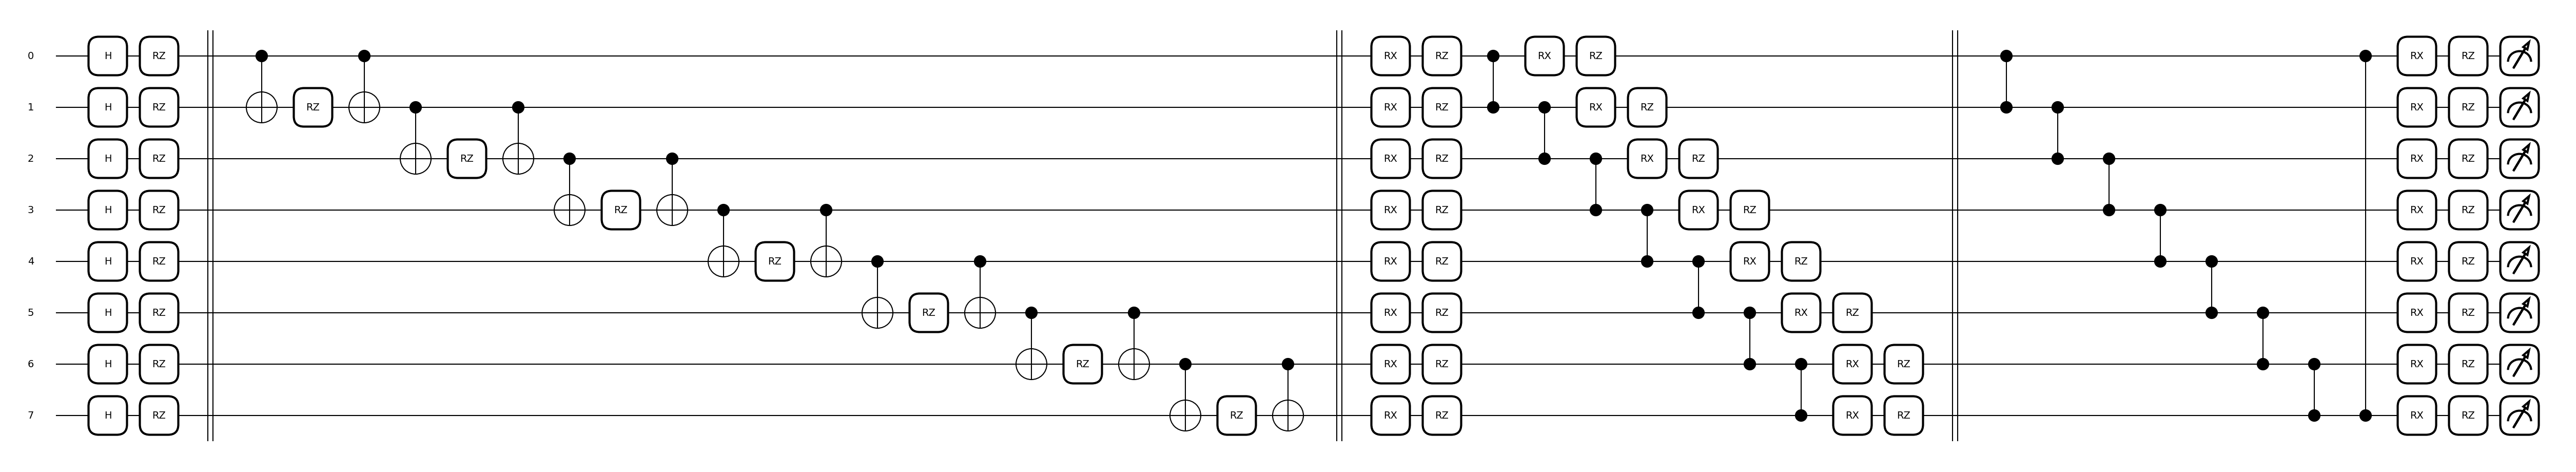

In [16]:
qml.draw_mpl(qlayer.qnode)()

In [33]:
qlayer.input_features

{'zzf_input': torch.Size([15])}

In [34]:
qlayer.zzf_input.params.shape

torch.Size([1, 15])

In [35]:
data = torch.rand((4, 15))

In [8]:
d = qlayer.qnode(data)

In [9]:
isinstance(d, torch.Tensor)

False

In [10]:
result = qlayer(data)

In [11]:
result

tensor([[ 0.3023,  0.2878,  0.0862,  0.1278,  0.0516,  0.0289,  0.2345,  0.1783],
        [ 0.0641,  0.4929,  0.1542,  0.2590,  0.3207, -0.0395,  0.0663,  0.0376],
        [ 0.0848,  0.2385,  0.1502,  0.2679,  0.0890, -0.0244,  0.1650,  0.1028],
        [ 0.3325,  0.4807,  0.1975,  0.3510,  0.5032,  0.2242,  0.1110,  0.1923]],
       dtype=torch.float64, grad_fn=<ViewBackward0>)

In [12]:
data.shape

torch.Size([4, 15])

(<Figure size 5000x900 with 1 Axes>, <Axes: >)

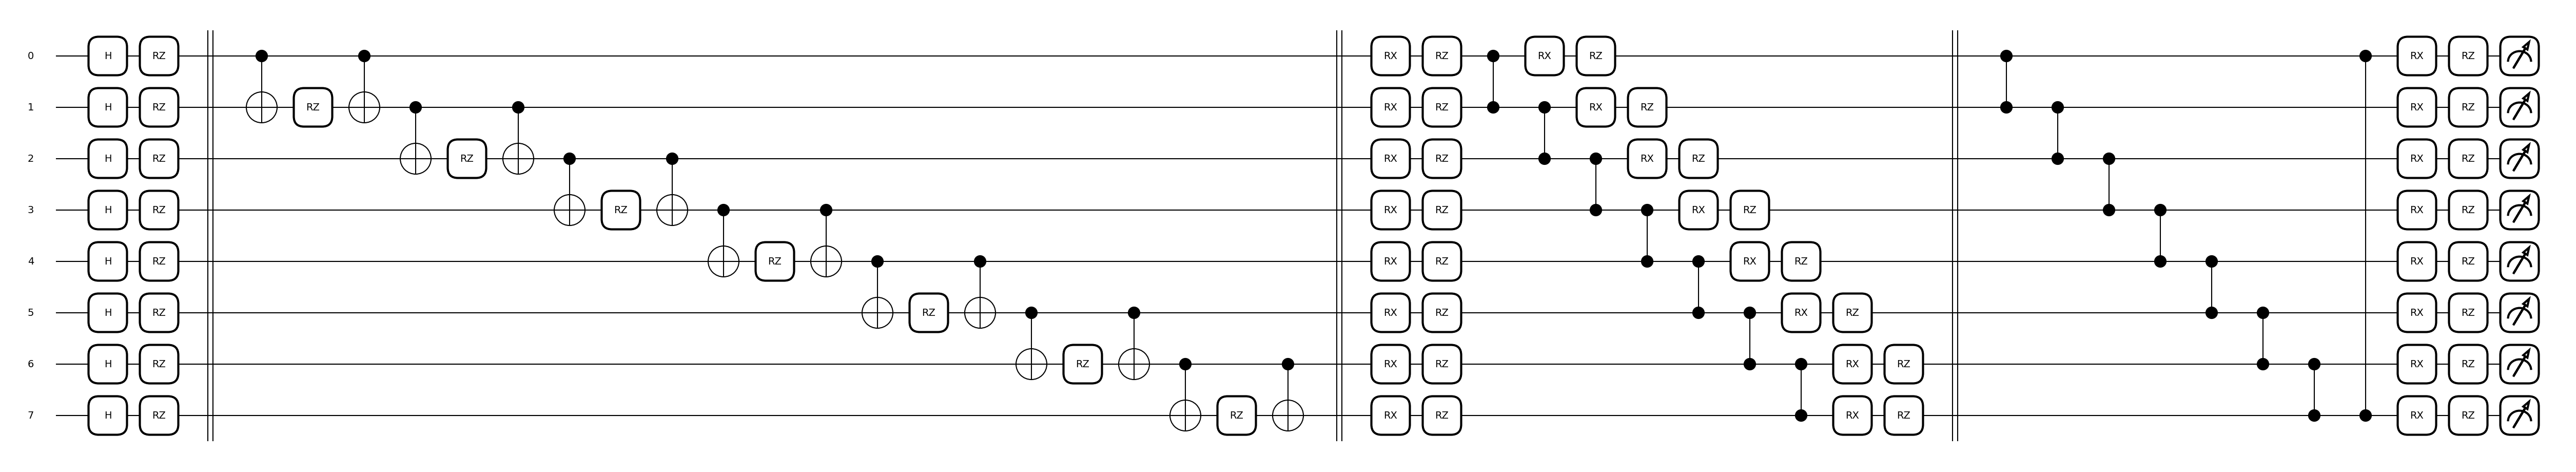

In [13]:
qml.draw_mpl(qlayer.qnode)(data)

## QAOA example

In [17]:
from pennylane.pauli import PauliSentence, PauliWord

In [74]:
class QAOA:
    def __init__(self, ops:PauliSentence, ansatz:QLayer):
        
        self.ops = ops
        self.ansatz = ansatz
class TrotterAnsatz(QSubLayer):
    def __init__(self, wires, ops):
        self.ops = ops
        super(TrotterAnsatz, self).__init__(wires, param_received=False)
    def init_weights(self):
        n = len(self.ops)
        return torch.rand(n)
    
    def _pauil2circuit(self, weight, pauli:PauliWord, wires=[]):
        n = len(pauli)
        cx_map = []
        w_last = wires[n-1]
        assert len(wires) >= n, f"Given Pauli word requires at least {n} wires."
        # Basis transformation
        for i, v in pauli.items():
            if v == "I": continue
            if v == "X":
                qml.Hadamard(i)
            elif v =="Y":
                qml.adjoint(qml.S(i))
                qml.Hadamard(i)
            cx_map.append(i)

        for cx_i in cx_map:
            qml.CNOT(wires[cx_i], w_last)
        
        qml.RZ(weight, wires=wires[w_last])
        
        for cx_i in reversed(cx_map):
            qml.CNOT(wires[cx_i], w_last)
        
        # Basis restoration
        for i, v in pauli.items():
            if v == "X":
                qml.Hadamard(i)
            elif v =="Y":
                qml.adjoint(qml.S(i))
                qml.Hadamard(i)
                
            
    def forward(self, wires=[]):
        assert len(wires) == (self.wires), "Applied wires must be matched with the defined qubit dimension."
        
        range_wires = range(self.wires)
        for p, pauli_word in zip(self.params, self.ops):
            self._pauil2circuit(p, pauli_word, range_wires)
        
#class QAOAAnsatz(QSubLayer):
#    def __init__(self, wires, ops:PauliSentence):
        

In [75]:
p1, p2, p3, p4 = PauliWord({0: "Z", 1:"Z"}), PauliWord({0: "Z", 2:"Z"}), PauliWord({1: "X", 1:"Z"}), PauliWord({3: "X", 4:"Z"})

In [76]:
str( p3)

'Z(1)'

In [77]:
ps = PauliSentence({
    p1: 0.3,
    p2: 0.1,
    p3:-0.4,
    p4: 0.3
})

In [78]:
t_layer = TrotterAnsatz(wires=5, ops=ps)

In [79]:
dev= qml.device("default.qubit", wires=5)
@qml.qnode(dev)
def circuit():
    t_layer(wires= range(5))


In [80]:
qml.draw_mpl(circuit)()

TypeError: 'int' object is not subscriptable

In [34]:
qml.adjoint(qml.S(0))

Adjoint(S(0))